In [2]:
import pandas as pd

# 1. Chargement du fichier Excel
# Assure-toi que le fichier est bien dans le même dossier que ton Notebook
df_bug = pd.read_excel('data_50_erreurs.xlsx')

# 2. Affichage des 10 premières lignes
print("Aperçu des 10 premières lignes :")
df_bug.head(10)

Aperçu des 10 premières lignes :


,Date,Produit,Prix_Unitaire,Quantite,Email_Client
0,2026-05-01,laptop,3200,2.0,amine@email.com
1,2026-05-01,Keyboard,4500,5.0,fatima@tech.ma
2,2026-05-01,laptop,0,4.0,sara.b@gmail.com
3,2026-05-01,laptop,12000,NaN,khalid@mail.com
4,2026-05-01,Monitor,3200,5.0,yassine@web.ma
5,2026-05-01,Laptop,1500,1.0,amine@email.com
6,2026-05-01,smartphone,8500,4.0,yassine@web.ma
7,2026-05-01,Tablet,-500,5.0,fatima@tech.ma
8,2026-05-01,laptop,8500,1.0,sara.b@gmail.com
9,2026-05-01,Smartphone,3200,3.0,yassine@web.ma


In [10]:
# 1. Chnou houma les types dyal les colonnes o wach kayn empty values?
print(df_bug.info())

<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           55 non-null     str    
 1   Produit        55 non-null     str    
 2   Prix_Unitaire  55 non-null     int64  
 3   Quantite       49 non-null     float64
 4   Email_Client   55 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 2.3 KB
None


In [3]:
# A. 7iyidi l-doublons
df_bug = df_bug.drop_duplicates()

In [4]:
# B. 7iyidi l-khawi (NaN)
df_bug = df_bug.dropna()

In [14]:
# C. 7ewwli l-date
df_bug['Date'] = pd.to_datetime(df_bug['Date'])

# D. N-qiw l-text (uniformisation)
df_bug['Produit'] = df_bug['Produit'].str.strip().str.capitalize()
# E. Vérification finale
print(df_bug.info())

<class 'pandas.DataFrame'>
Index: 45 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           45 non-null     datetime64[us]
 1   Produit        45 non-null     str           
 2   Prix_Unitaire  45 non-null     int64         
 3   Quantite       45 non-null     float64       
 4   Email_Client   45 non-null     str           
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 2.1 KB
None


In [5]:
import numpy as np

# 1. 7ssbi l-CA (Chiffre d'Affaire) total
df_bug['Total'] = df_bug['Prix_Unitaire'] * df_bug['Quantite']

# 2. NumPy Challenge: Zidi colonne "Promotion" 
# Ila kan l-Total kbar men 20,000 DH, diro remise dyal 15%, sinon 0%
df_bug['Remise'] = np.where(df_bug['Total'] > 20000, 0.15, 0)

# 3. 7ssbi l-prix l-final li ghadi i-khless l-client
df_bug['Prix_Final'] = df_bug['Total'] * (1 - df_bug['Remise'])

print("L-7ssabat t-zadou b nja7!")
df_bug.head()

L-7ssabat t-zadou b nja7!


,Date,Produit,Prix_Unitaire,Quantite,Email_Client,Total,Remise,Prix_Final
0,2026-05-01,laptop,3200,2.0,amine@email.com,6400.0,0.00,6400.0
1,2026-05-01,Keyboard,4500,5.0,fatima@tech.ma,22500.0,0.15,19125.0
2,2026-05-01,laptop,0,4.0,sara.b@gmail.com,0.0,0.00,0.0
4,2026-05-01,Monitor,3200,5.0,yassine@web.ma,16000.0,0.00,16000.0
5,2026-05-01,Laptop,1500,1.0,amine@email.com,1500.0,0.00,1500.0


In [6]:
# 1. Filtrage des données : On ne garde que les produits dont le prix est strictement supérieur à 0
# Cette étape permet d'éliminer les erreurs de saisie ou les données manquantes
df_bug = df_bug[df_bug['Prix_Unitaire'] > 0]

# 2. Vérification
print("Nettoyage terminé : Les lignes avec un prix nul (0 DH) ont été supprimées.")
print(f"Nouveau nombre de lignes : {len(df_bug)}")

Nettoyage terminé : Les lignes avec un prix nul (0 DH) ont été supprimées.
Nouveau nombre de lignes : 35


In [8]:
# Mettre tout en minuscules pour ne plus avoir de doublons de noms
df_bug['Produit'] = df_bug['Produit'].str.lower().str.strip()



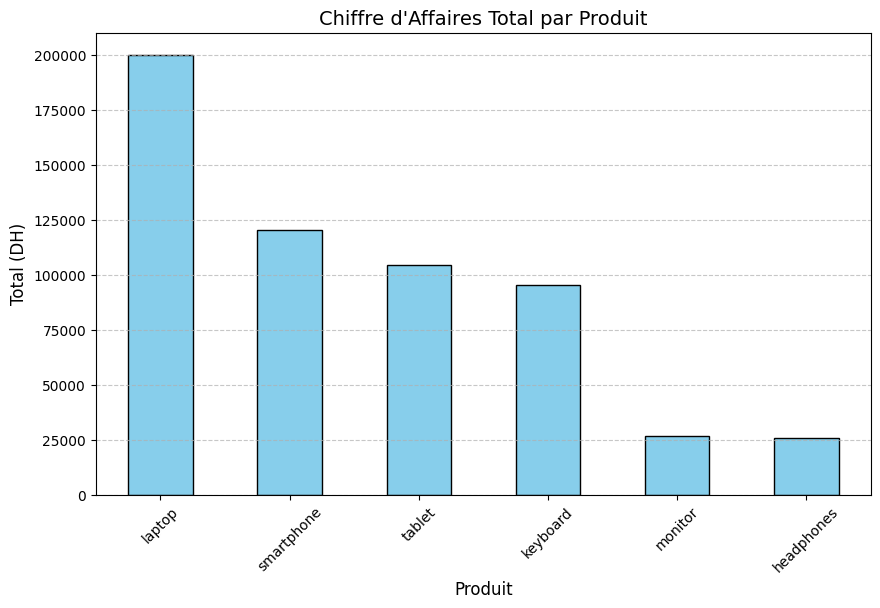

In [9]:
import matplotlib.pyplot as plt

# 1. Grouping: N-jm3o l-Total dyal kol produit
ventes_par_produit = df_bug.groupby('Produit')['Total'].sum().sort_values(ascending=False)

# 2. Graphique: Rsm mibyane b l-barres
plt.figure(figsize=(10, 6))
ventes_par_produit.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Beautify: N-qaddi s-miyat o l-alwan
plt.title('Chiffre d\'Affaires Total par Produit', fontsize=14)
plt.xlabel('Produit', fontsize=12)
plt.ylabel('Total (DH)', fontsize=12)
plt.xticks(rotation=45) # Bach s-miyat i-banou mzyan
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Affichage
plt.show()

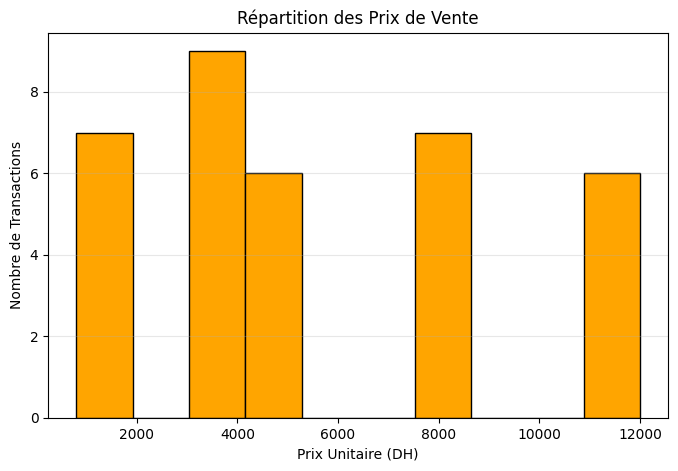

In [10]:
#1. L'Histogramme (La Distribution)
import matplotlib.pyplot as plt

# Question : Quelle est la répartition (fréquence) des prix unitaires dans nos ventes ?
plt.figure(figsize=(8, 5))
plt.hist(df_bug['Prix_Unitaire'], bins=10, color='orange', edgecolor='black')

plt.title('Répartition des Prix de Vente')
plt.xlabel('Prix Unitaire (DH)')
plt.ylabel('Nombre de Transactions')
plt.grid(axis='y', alpha=0.3)
plt.show()

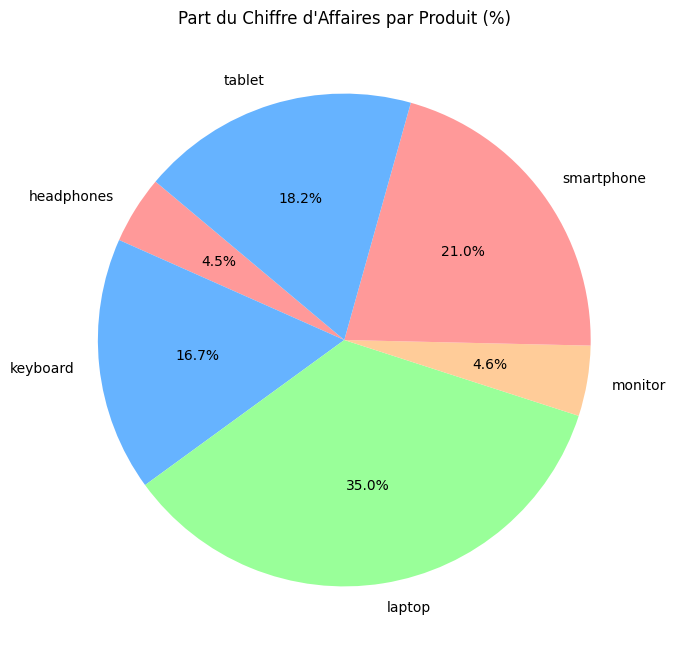

In [ ]:
# Le Pie Chart (La Part de Marché)= Diagramme circulaire.
# Préparation des données : Somme du Total par produit
ca_par_produit = df_bug.groupby('Produit')['Total'].sum()

# Question : Quel est le pourcentage de contribution de chaque produit au revenu total ?
plt.figure(figsize=(8, 8))
plt.pie(ca_par_produit, labels=ca_par_produit.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title('Part du Chiffre d\'Affaires par Produit (%)')
plt.show()

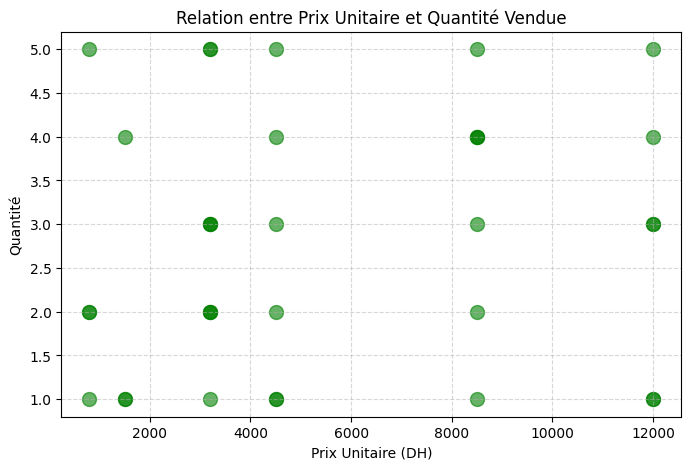

In [ ]:
#Le Scatter Plot (La Corrélation)= Nuage de points.
# Question : Est-ce que les clients achètent de plus petites quantités quand le prix est plus élevé ?
plt.figure(figsize=(8, 5))
plt.scatter(df_bug['Prix_Unitaire'], df_bug['Quantite'], color='green', alpha=0.6, s=100)

plt.title('Relation entre Prix Unitaire et Quantité Vendue')
plt.xlabel('Prix Unitaire (DH)')
plt.ylabel('Quantité')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

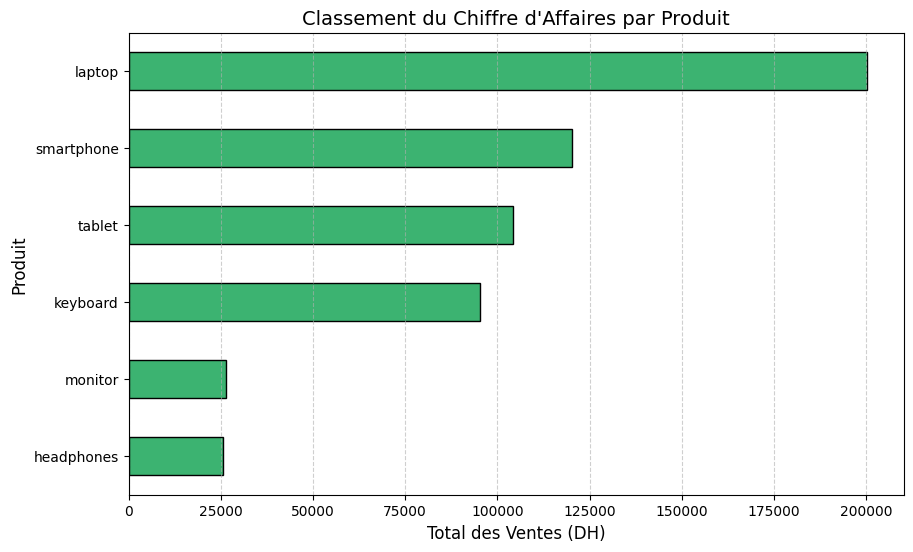

In [ ]:
#Le Bar Chart Horizontal ( Diagramme à barres horizontale)
import matplotlib.pyplot as plt

# 1. Préparation des données (on trie par ordre croissant pour que le plus grand soit en haut du graphique)
ca_par_produit = df_bug.groupby('Produit')['Total'].sum().sort_values(ascending=True)

# 2. Création du graphique horizontal
plt.figure(figsize=(10, 6))
# 'barh' signifie bar horizontal
ca_par_produit.plot(kind='barh', color='mediumseagreen', edgecolor='black')

# 3. Documentation et Esthétique
plt.title('Classement du Chiffre d\'Affaires par Produit', fontsize=14)
plt.xlabel('Total des Ventes (DH)', fontsize=12)
plt.ylabel('Produit', fontsize=12)

# Ajout d'une grille sur l'axe X pour mieux lire les montants
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()